<a href="https://colab.research.google.com/github/MarceloX2115/Visualizacao_de_dados/blob/main/Visualiza%C3%A7%C3%A3o_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Desafios de Visualização de Dados**

Recursos Úteis:

 * Data Viz Project: https://datavizproject.com/input/c/ - Um catálogo visual de gráficos para explorar.

* From Data to Viz: https://www.data-to-viz.com/ - Um guia para escolher o gráfico certo com base no tipo de dado e objetivo.

* Documentação Seaborn: https://seaborn.pydata.org/ - Para detalhes sobre os parâmetros de estilo e plotagem.

* Documentação Matplotlib: https://matplotlib.org/stable/contents.html - Para controle fino sobre elementos do gráfico.



## **0: Configuração Inicial**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações padrão para gráficos (para começar limpo)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

print("Bibliotecas importadas e configurações aplicadas!")

Bibliotecas importadas e configurações aplicadas!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1: Desafios de Decisão

Para cada cenário abaixo, você receberá um conjunto de dados e uma pergunta de negócio. Sua tarefa é:

1. Analisar a pergunta e o tipo de dado.

2. Consultar o Data Viz Project ou From Data to Viz para identificar o tipo de gráfico mais adequado.

3. Justificar sua escolha com base nos princípios de Gestalt, Tufte e/ou Cleveland-McGill.

4. Implementar o gráfico usando matplotlib e seaborn. Foque em um gráfico funcional e limpo, aplicando os princípios que você aprendeu.

Desafio 1.1: Comparação de Vendas por Região

Cenário: Uma empresa de varejo quer comparar o desempenho de vendas de suas quatro regiões no último trimestre para identificar qual delas precisa de mais atenção.



In [3]:
# Dados para o Desafio 1.1
dados_regiao = {
    'Regiao': ['Norte', 'Sul', 'Leste', 'Oeste'],
    'Vendas_Milhoes': [12.5, 18.2, 15.0, 9.8]
}
df_regiao = pd.DataFrame(dados_regiao)
print("\nDataFrame para Desafio 1.1:")
print(df_regiao)


DataFrame para Desafio 1.1:
  Regiao  Vendas_Milhoes
0  Norte            12.5
1    Sul            18.2
2  Leste            15.0
3  Oeste             9.8


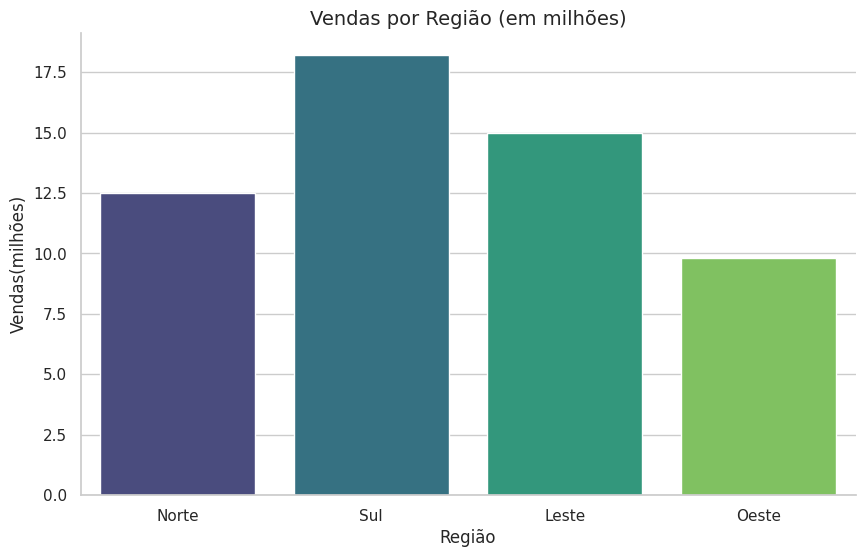

In [4]:
# Escreva sua justificativa aqui:
# 1. Tipo de gráfico escolhido: Eu escolhi o grafico de barras vertical, pela sua demonstração da diferença nos dados na facilidade do olho humano comprara suas diferenças
# 2. Justificativa (Cleveland-McGill, Gestalt): Atraves do Cleveland-McGill a recomendação de uso do grafico de barras pela sua demonstração de dados em um prazo é facilitado por causa do olhar humano na comparação deles,
# e usando o método de Gestalt, da para usar o princípio de semelhança ja que no grafico possui formas semelhantes(retangulos verticais) e poderia também ter cores semelhantes

# Seu código Python para o gráfico:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Regiao',
    y='Vendas_Milhoes',
    data=df_regiao,
    palette='viridis',
    hue='Regiao',
    legend=False
)
plt.title('Vendas por Região (em milhões)', fontsize='14')
plt.xlabel('Região')
plt.ylabel('Vendas(milhões)')
sns.despine()
plt.show()

Desafio 1.2: Distribuição de Idades de Clientes

Cenário: Uma equipe de marketing quer entender a distribuição de idade de seus clientes para segmentar campanhas. Eles têm dados de idade de 1000 clientes.

In [5]:
# Dados para o Desafio 1.2
np.random.seed(42)
idades = np.random.normal(loc=35, scale=10, size=1000).astype(int)
idades = idades[(idades >= 18) & (idades <= 70)] # Limitar idades razoáveis
df_idades = pd.DataFrame({'Idade': idades})
print("\nDataFrame para Desafio 1.2 (primeiras 5 linhas):")
print(df_idades.head())


DataFrame para Desafio 1.2 (primeiras 5 linhas):
   Idade
0     39
1     33
2     41
3     50
4     32


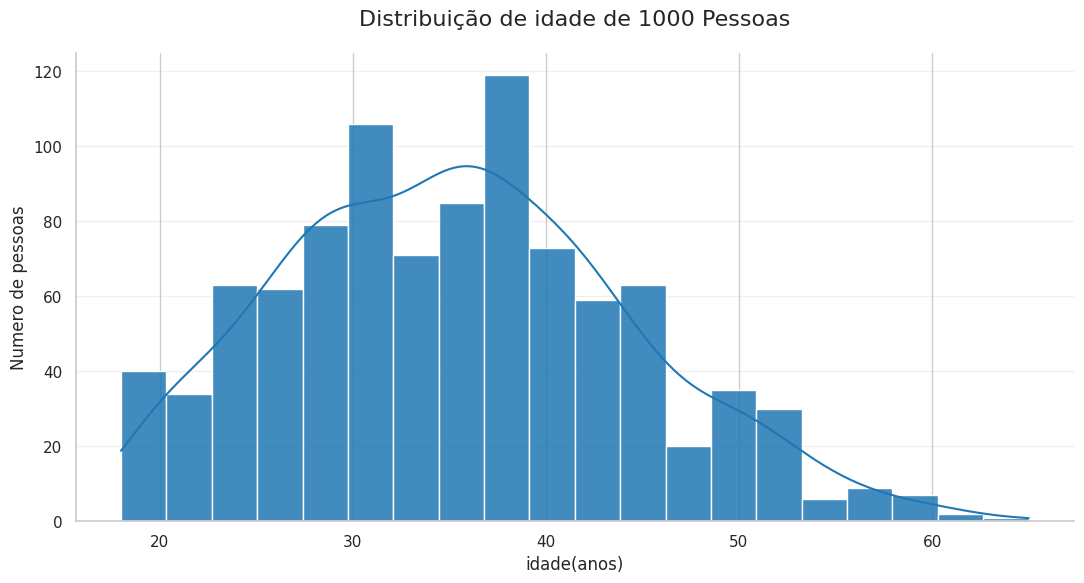

In [6]:
# Escreva sua justificativa aqui:
# 1. Tipo de gráfico escolhido: Eu usaria o grafico Histograma, pois idade é uma variavel considerada continua, e o histograma é melhor em mostrar a forma de distribuição de idade
# 2. Justificativa (Cleveland-McGill, Gestalt):O histograma foi escolhido porque permite visualizar a distribuição de uma variável contínua de forma clara.
#Segundo a hierarquia de Cleveland-McGill, a posição das barras ao longo de uma escala comum oferece alta precisão na comparação de frequências.
#Do ponto de vista da Gestalt, o princípio da proximidade reforça a continuidade da idade, enquanto a similaridade das barras cria unidade visual. O KDE adicionado ajuda na percepção da forma geral da distribuição (continuidade).

# Seu código Python para o gráfico:
plt.figure(figsize=(11, 6))
sns.histplot(
    idades,
    bins=20,
    kde=True,
    color='#1f77b4',
    edgecolor='white',
    alpha=0.85
)
plt.title('Distribuição de idade de 1000 Pessoas',fontsize = 16, pad=20)
plt.xlabel('idade(anos)',fontsize=12)
plt.ylabel('Numero de pessoas',fontsize=12)
sns.despine()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Desafio 1.3: Tendência de Acessos ao Site

Cenário: A equipe de produto quer monitorar a evolução diária do número de acessos ao site nos últimos 30 dias para identificar padrões ou quedas.

In [ ]:
# Dados para o Desafio 1.3
datas = pd.date_range(start='2024-03-01', periods=30)
np.random.seed(42)
acessos = np.random.randint(1000, 5000, 30)
# Simular uma queda nos últimos dias
acessos[-5:] = np.random.randint(500, 1500, 5)
df_acessos = pd.DataFrame({'Data': datas, 'Acessos': acessos})
print("\nDataFrame para Desafio 1.3 (primeiras 5 linhas):")
print(df_acessos.head())


DataFrame para Desafio 1.3 (primeiras 5 linhas):
        Data  Acessos
0 2024-03-01     4174
1 2024-03-02     4507
2 2024-03-03     1860
3 2024-03-04     2294
4 2024-03-05     2130


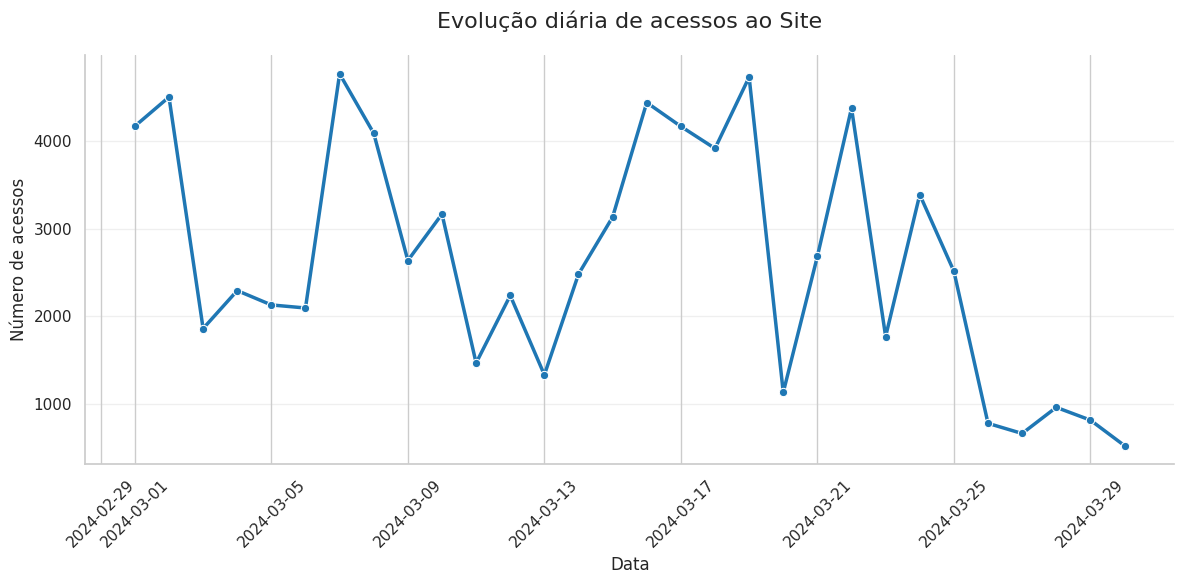

In [ ]:
# Escreva sua justificativa aqui:
# 1. Tipo de gráfico escolhido: O gráfico escolhido foi o grafico de linha
# 2. Justificativa (Cleveland-McGill, Gestalt): Usando o cleveland-McGill, o gráfico de linha é recomendado para esses dados pela sua organização de um dado mais preciso ao menos preciso, e pelo Gestalt é
#pelo motivo da continuidade e conexão que o grafico oferece para os dados mostrados

# Seu código Python para o gráfico:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_acessos,
    x='Data',
    y='Acessos',
    color='#1f77b4',
    linewidth=2.5,
    marker='o',
    markersize =6
)
plt.title("Evolução diária de acessos ao Site", fontsize=16, pad=20)
plt.xlabel('Data',fontsize=12)
plt.ylabel('Número de acessos',fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

Desafio 1.4: Relação entre Investimento em Marketing e Vendas

Cenário: A equipe de finanças quer entender se há uma correlação entre o investimento mensal em marketing e o volume de vendas gerado no mesmo mês.

In [7]:
# Dados para o Desafio 1.4
np.random.seed(42)
investimento_marketing = np.random.randint(10000, 50000, 12)
vendas_mensais = investimento_marketing * 5 + np.random.randint(-5000, 5000, 12)
df_marketing_vendas = pd.DataFrame({
    'Investimento_Marketing': investimento_marketing,
    'Vendas_Mensais': vendas_mensais
})
print("\nDataFrame para Desafio 1.4 (primeiras 5 linhas):")
print(df_marketing_vendas.head())


DataFrame para Desafio 1.4 (primeiras 5 linhas):
   Investimento_Marketing  Vendas_Mensais
0                   25795          129286
1                   10860           54351
2                   48158          242210
3                   21284          102604
4                   16265           80880


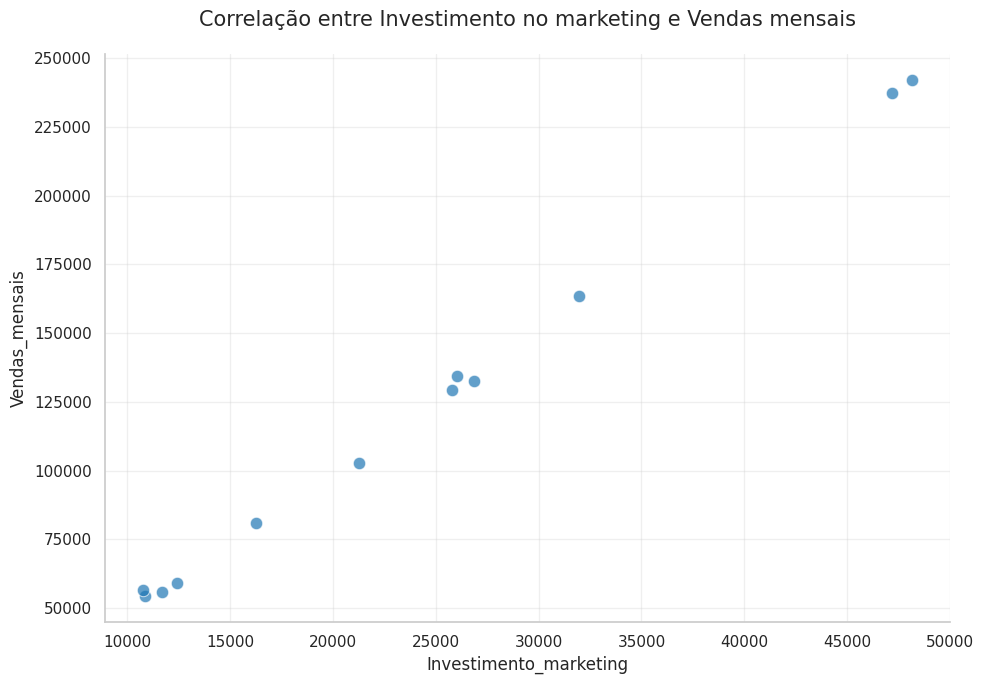

In [ ]:
# Escreva sua justificativa aqui:
# 1. Tipo de gráfico escolhido: O gráfico escolhido foi o gráfico de dispersão
# 2. Justificativa (Cleveland-McGill, Gestalt): Escolhi o gráfico de dispersão porque ele é ideal para visualizar a relação entre duas variáveis quantitativas contínuas.
#Pois pela hierarquia de Cleveland-McGill, ele se beneficia do encoding mais preciso: a posição ao longo de escalas comuns (eixos x e y), permitindo julgamentos altamente exatos sobre os valores e a correlação.
#E pelo Gestalt, a proximidade ajuda a identificar clusters, a similaridade unifica os pontos como um único conjunto de dados, e a continuidade facilita a percepção de tendências ou padrões lineares na relação entre investimento em marketing e vendas mensais.


# Seu código Python para o gráfico:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_marketing_vendas,
    x='Investimento_Marketing',
    y='Vendas_Mensais',
    color='#1f77b4',
    alpha=0.7,
    s=80
)
plt.title('Correlação entre Investimento no marketing e Vendas mensais',fontsize=15, pad=20)
plt.xlabel('Investimento_marketing', fontsize=12)
plt.ylabel('Vendas_mensais',fontsize=12)
sns.despine()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Desafio 1.5: Composição de Mercado por Categoria de Produto

Cenário: Um analista de mercado quer visualizar a proporção de cada categoria de produto no total de vendas da empresa para entender a dominância de certas categorias.

In [8]:
# Dados para o Desafio 1.5
dados_categorias = {
    'Categoria': ['Eletrônicos', 'Vestuário', 'Alimentos', 'Livros', 'Serviços'],
    'Vendas_Milhoes': [35.0, 20.0, 15.0, 10.0, 5.0]
}
df_categorias = pd.DataFrame(dados_categorias)
print("\nDataFrame para Desafio 1.5:")
print(df_categorias)


DataFrame para Desafio 1.5:
     Categoria  Vendas_Milhoes
0  Eletrônicos            35.0
1    Vestuário            20.0
2    Alimentos            15.0
3       Livros            10.0
4     Serviços             5.0


/tmp/ipykernel_25235/3326824260.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


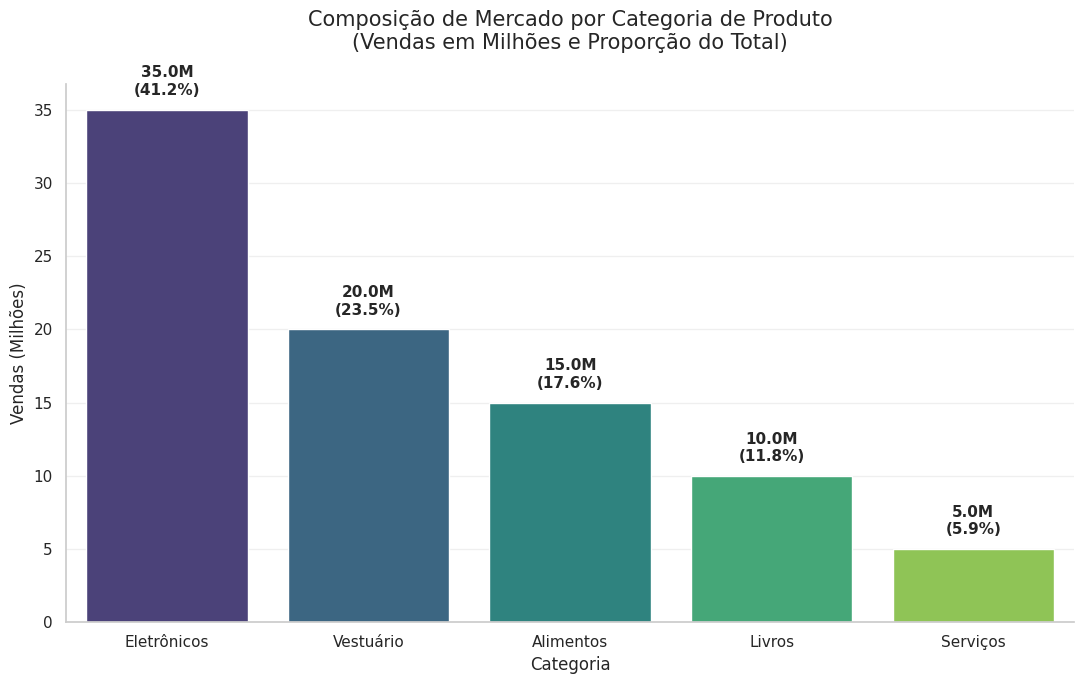

In [13]:
# Escreva sua justificativa aqui:
# 1. Tipo de gráfico escolhido: Gráfico de Barras (Bar Plot)

# 2. Justificativa (Cleveland-McGill, Gestalt):O gráfico de barras foi selecionado por permitir uma comparação precisa entre as categorias de produto.
#Pela hierarquia de Cleveland e McGill, ele utiliza o encoding mais preciso: posição ao longo de uma escala comum, facilitando a percepção exata das diferenças de vendas entre categorias.
#Aplicando os princípios da Gestalt: a proximidade das barras permite fácil comparação, a similaridade reforça a unidade do conjunto de dados, e a continuidade da linha de base ajuda
#na identificação da dominância de cada categoria (ex.: Eletrônicos representa a maior fatia do mercado)

# Seu código Python para o gráfico:

# Calcular percentuais
df_categorias['Percentual'] = (df_categorias['Vendas_Milhoes'] /
                               df_categorias['Vendas_Milhoes'].sum() * 100).round(1)

plt.figure(figsize=(11, 7))
ax = sns.barplot(
    data=df_categorias,
    x='Categoria',
    y='Vendas_Milhoes',
    palette='viridis',
    edgecolor='white'
)

for i, v in enumerate(df_categorias['Vendas_Milhoes']):
    perc = df_categorias['Percentual'].iloc[i]
    ax.text(i, v + 0.8, f"{v}M\n({perc}%)",
            ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('Composição de Mercado por Categoria de Produto\n(Vendas em Milhões e Proporção do Total)',
          fontsize=15, pad=25)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Vendas (Milhões)', fontsize=12)

sns.despine()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Parte 2: Desafios de Refatoração Crítica

Para cada cenário abaixo, você receberá um código Python que gera um gráfico com problemas de design. Sua tarefa é:

1. Analisar o gráfico gerado e identificar pelo menos 3 problemas com base nos princípios de Tufte (Data-Ink Ratio, Lie Factor, Chartjunk), Gestalt (Proximidade, Semelhança, Fechamento, etc.) e/ou Cleveland-McGill (eficácia da codificação).

2. Descrever os problemas identificados.

3. Modificar o código para refatorar o gráfico, aplicando os princípios para torná-lo mais honesto, eficiente e visualmente claro.



Desafio 2.1: Vendas Trimestrais com Eixo Y Enganoso

Cenário: Um gerente de vendas recebeu este gráfico e está preocupado com uma suposta queda drástica nas vendas do Q4.

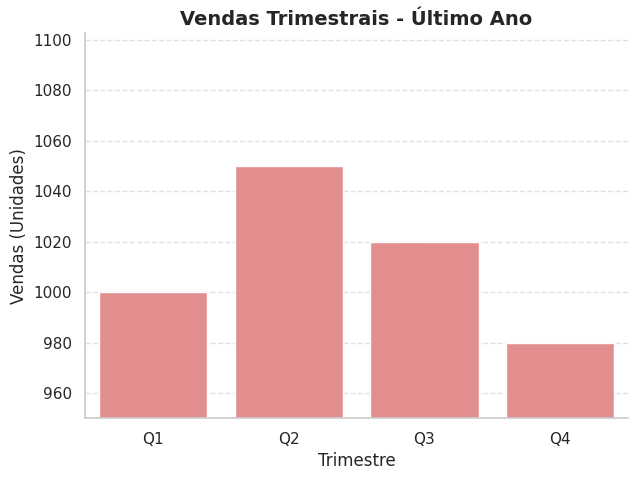

In [ ]:
# Dados para o Desafio 2.1
dados_trimestrais = {
    'Trimestre': ['Q1', 'Q2', 'Q3', 'Q4'],
    'Vendas': [1000, 1050, 1020, 980]
}
df_trimestral = pd.DataFrame(dados_trimestrais)

plt.figure(figsize=(7, 5))
ax = sns.barplot(x='Trimestre', y='Vendas', data=df_trimestral, color='lightcoral')
ax.set_ylim(bottom=950) # Eixo Y começando alto
ax.set_title('Vendas Trimestrais - Último Ano', fontsize=14, fontweight='bold')
ax.set_xlabel('Trimestre')
ax.set_ylabel('Vendas (Unidades)')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

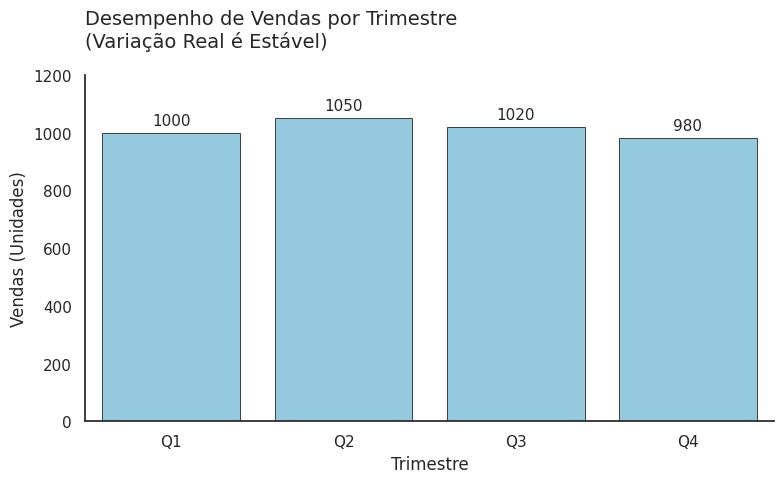

In [14]:
# 1. Problemas identificados:
#a)Eixo Y Truncado (Lie Factor): O gráfico começa em 950 em vez de 0. Isso exagera visualmente a queda no Q4, fazendo uma variação de apenas 4% parecer um colapso catastrófico.
#b)Baixo Data-Ink Ratio (Chartjunk): O uso de barras largas e coloridas para apenas quatro valores é ineficiente. As linhas de grade ao fundo poluem o visual sem ajudar na leitura precisa dos números.
#c)Codificação Inadequada (Cleveland-McGill): Para dados temporais (trimestres), a posição em uma linha é mais eficaz que o volume de barras. Barras sugerem quantidades independentes; linhas sugerem continuidade e tendência.
# 2. Seu código Python refatorado:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dados para o Desafio 2.1
dados_trimestrais = {
    'Trimestre': ['Q1', 'Q2', 'Q3', 'Q4'],
    'Vendas': [1000, 1050, 1020, 980]
}
df_trimestral = pd.DataFrame(dados_trimestrais)

plt.figure(figsize=(8, 5))
sns.set_style("white")

ax = sns.barplot(x='Trimestre', y='Vendas', data=df_trimestral, color='skyblue', edgecolor='black', linewidth=0.5)
# 1. Correção Crucial: Eixo Y começando em 0
ax.set_ylim(0, 1200)
# 2. Aumentando o Data-Ink Ratio: Removendo bordas desnecessárias (spines)
sns.despine()
# 3. Adicionando rótulos de dados diretamente nas barras (Gestalt: Proximidade)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11)
# Títulos e labels claros
plt.title('Desempenho de Vendas por Trimestre\n(Variação Real é Estável)', fontsize=14, loc='left', pad=20)
plt.xlabel('Trimestre', fontsize=12)
plt.ylabel('Vendas (Unidades)', fontsize=12)
# Ajuste fino
plt.tight_layout()
plt.show()

Desafio 2.2: Comparação de Produtos com Gráfico de Pizza Lotado

Cenário: A equipe de produto quer ver a proporção de vendas de 8 produtos diferentes, mas o gráfico atual está confuso.

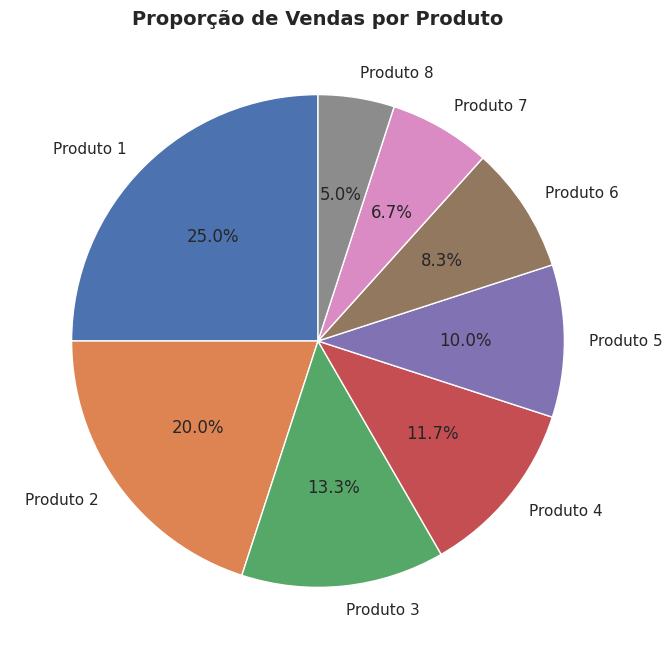

In [ ]:
# Dados para o Desafio 2.2
dados_produtos = {
    'Produto': [f'Produto {i}' for i in range(1, 9)],
    'Vendas': [150, 120, 80, 70, 60, 50, 40, 30]
}
df_produtos = pd.DataFrame(dados_produtos)

plt.figure(figsize=(8, 8))
plt.pie(df_produtos['Vendas'], labels=df_produtos['Produto'], autopct='%1.1f%%', startangle=90)
plt.title('Proporção de Vendas por Produto', fontsize=14, fontweight='bold')
plt.show()

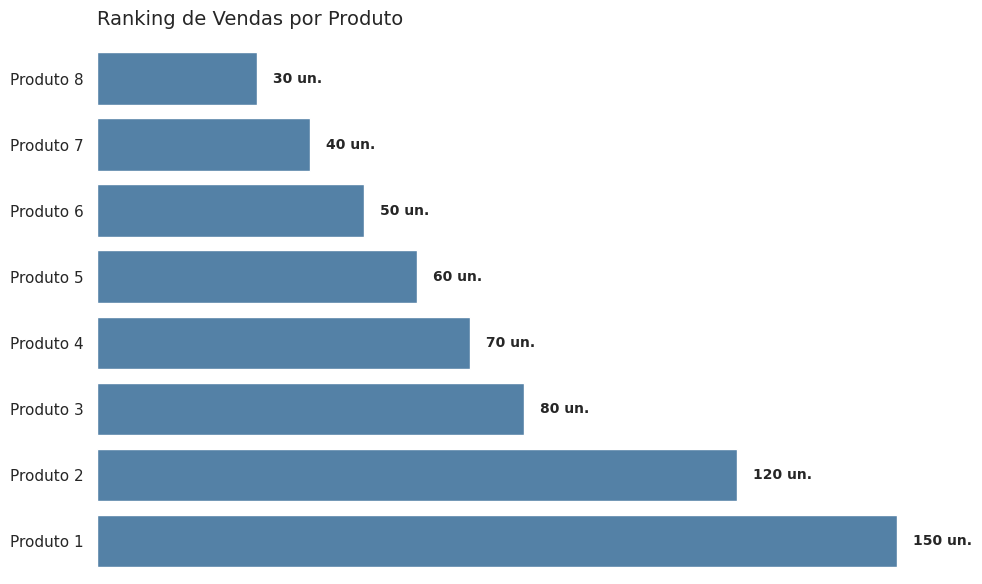

In [16]:
# 1. Problemas identificados:
#    a)Eixo Y Truncado (Lie Factor): O gráfico começa em 950 em vez de 0. Isso exagera visualmente a queda no Q4, fazendo uma variação de apenas 4% parecer um colapso catastrófico.
#    b)Baixo Data-Ink Ratio (Chartjunk): O uso de barras largas e coloridas para apenas quatro valores é ineficiente. As linhas de grade ao fundo poluem o visual sem ajudar na leitura precisa dos números.
#    c)Codificação Inadequada (Cleveland-McGill): Para dados temporais (trimestres), a posição em uma linha é mais eficaz que o volume de barras. Barras sugerem quantidades independentes; linhas sugerem continuidade e tendência.

# 2. Seu código Python refatorado:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dados
dados_produtos = {
    'Produto': [f'Produto {i}' for i in range(1, 9)],
    'Vendas': [150, 120, 80, 70, 60, 50, 40, 30]
}
df_produtos = pd.DataFrame(dados_produtos)

df_produtos = df_produtos.sort_values('Vendas', ascending=True)

plt.figure(figsize=(10, 6))
sns.set_style("white")

ax = sns.barplot(x='Vendas', y='Produto', data=df_produtos, color='steelblue')


sns.despine(left=True, bottom=True)
ax.set_xticks([])

for i, v in enumerate(df_produtos['Vendas']):
    ax.text(v + 3, i, f'{v} un.', va='center', fontsize=10, fontweight='bold')

plt.title('Ranking de Vendas por Produto', fontsize=14, loc='left', pad=15)
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

Desafio 2.3: Desempenho de Funcionários com Cores Aleatórias

Cenário: O RH quer visualizar o desempenho (pontuação de 0 a 100) de 5 funcionários em uma avaliação, mas o gráfico atual usa cores sem sentido.

/tmp/ipykernel_1290/178950125.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Funcionario', y='Pontuacao', data=df_funcionarios, palette=cores_aleatorias)


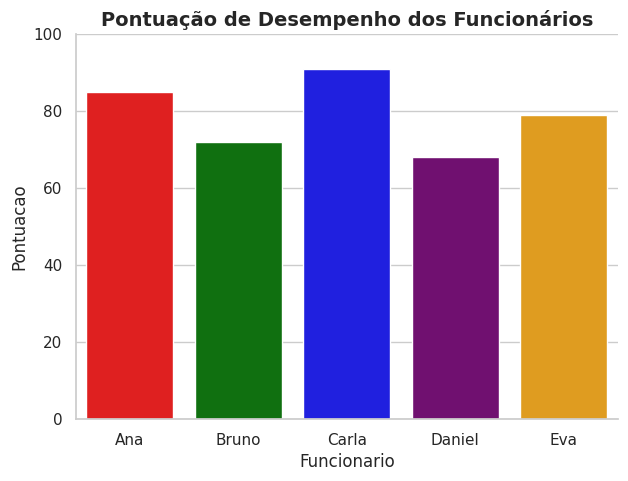

In [ ]:
# Dados para o Desafio 2.3
dados_funcionarios = {
    'Funcionario': ['Ana', 'Bruno', 'Carla', 'Daniel', 'Eva'],
    'Pontuacao': [85, 72, 91, 68, 79]
}
df_funcionarios = pd.DataFrame(dados_funcionarios)

plt.figure(figsize=(7, 5))
cores_aleatorias = ['red', 'green', 'blue', 'purple', 'orange']
ax = sns.barplot(x='Funcionario', y='Pontuacao', data=df_funcionarios, palette=cores_aleatorias)
ax.set_title('Pontuação de Desempenho dos Funcionários', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
plt.show()

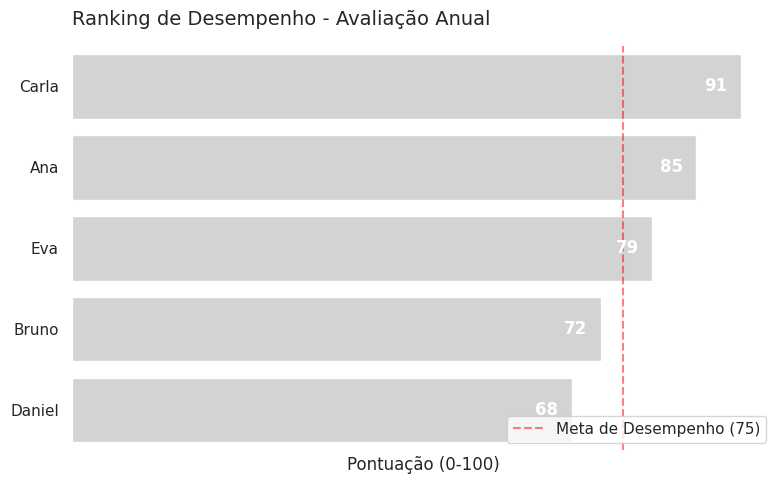

In [17]:
# 1. Problemas identificados:
#a) Violação da Semelhança (Gestalt): O uso de cores diferentes para a mesma métrica (Pontuação) sugere, erroneamente, que existe uma categoria ou significado distinto para cada funcionário, o que confunde o cérebro.
#b)Baixo Data-Ink Ratio (Tufte): As cores aleatórias são "tinta" que não comunica informação nova. Elas criam ruído visual e podem carregar conotações não planejadas (ex: vermelho sugerindo erro ou perigo).
#c)Falta de Ordenação (Cleveland-McGill): Apresentar os dados em ordem alfabética ou aleatória exige mais esforço para identificar quem teve o melhor ou pior desempenho. A ordenação por valor facilita a comparação imediata.

# 2. Seu código Python refatorado:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dados
dados_funcionarios = {
    'Funcionario': ['Ana', 'Bruno', 'Carla', 'Daniel', 'Eva'],
    'Pontuacao': [85, 72, 91, 68, 79]
}
df_f = pd.DataFrame(dados_funcionarios).sort_values('Pontuacao', ascending=False)

plt.figure(figsize=(8, 5))
sns.set_style("white")

# Refatoração: Cor única e neutra para evitar distrações
ax = sns.barplot(x='Pontuacao', y='Funcionario', data=df_f, color='lightgray')

# Adicionando linha de meta (Contexto)
plt.axvline(75, color='red', linestyle='--', alpha=0.5, label='Meta de Desempenho (75)')

# Rótulos diretos (Data-Ink Ratio)
for i, v in enumerate(df_f['Pontuacao']):
    ax.text(v - 5, i, str(v), color='white', va='center', fontweight='bold')

sns.despine(left=True, bottom=True)
plt.title('Ranking de Desempenho - Avaliação Anual', fontsize=14, loc='left', pad=15)
plt.xlabel('Pontuação (0-100)')
plt.ylabel('')
plt.xticks([])
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Desafio 2.4: Gráfico de Linhas com Chartjunk Excessivo

Cenário: Um analista de dados criou este gráfico para mostrar a evolução de duas métricas ao longo do tempo, mas ele está muito poluído.

/tmp/ipykernel_1290/3038338850.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datas_mes = pd.date_range(start='2023-01-01', periods=12, freq='M')


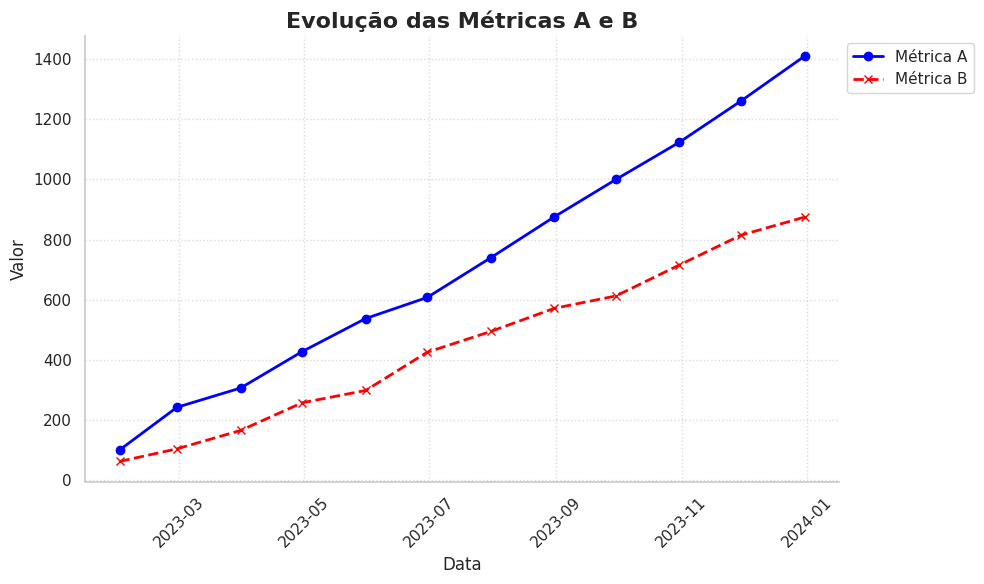

In [ ]:
# Dados para o Desafio 2.4
datas_mes = pd.date_range(start='2023-01-01', periods=12, freq='M')
np.random.seed(42)
metrica_a = np.random.randint(50, 150, 12).cumsum()
metrica_b = np.random.randint(40, 130, 12).cumsum()

df_metricas = pd.DataFrame({
    'Data': datas_mes,
    'Metrica_A': metrica_a,
    'Metrica_B': metrica_b
})

plt.figure(figsize=(10, 6))
plt.plot(df_metricas['Data'], df_metricas['Metrica_A'], label='Métrica A', marker='o', linestyle='-', linewidth=2, color='blue')
plt.plot(df_metricas['Data'], df_metricas['Metrica_B'], label='Métrica B', marker='x', linestyle='--', linewidth=2, color='red')

plt.title('Evolução das Métricas A e B', fontsize=16, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Valor', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_25235/3630247141.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datas_mes = pd.date_range(start='2023-01-01', periods=12, freq='M')


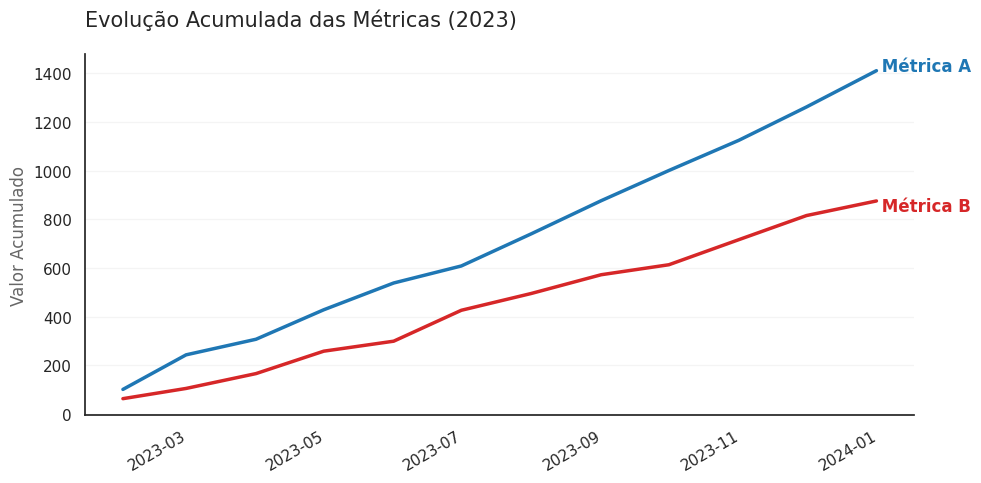

In [19]:
# 1. Problemas identificados:
#a)Baixo Data-Ink Ratio (Tufte): O uso simultâneo de linhas sólidas, pontilhadas, marcadores redondos ('o') e marcadores em 'x' cria muito ruído. A "tinta" usada nos marcadores e na grade pesada não ajuda na interpretação e polui o campo visual.
#b)Problemas de Proximidade e Fechamento (Gestalt): A legenda posicionada fora do gráfico (bbox_to_anchor) força o olho do leitor a viajar constantemente de um lado para o outro para identificar qual linha pertence a qual métrica.
#c)Poluição do Eixo (Cleveland-McGill): A rotação de 45 graus nos rótulos de data dificulta a leitura natural e sugere que o gráfico está "apertado". Além disso, a grade pontilhada muito densa cria um padrão de "Moiré" que cansa a vista.

# 2. Seu código Python refatorado:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dados
datas_mes = pd.date_range(start='2023-01-01', periods=12, freq='M')
np.random.seed(42)
metrica_a = np.random.randint(50, 150, 12).cumsum()
metrica_b = np.random.randint(40, 130, 12).cumsum()

df_metricas = pd.DataFrame({'Data': datas_mes, 'Metrica_A': metrica_a, 'Metrica_B': metrica_b})

# Início da Refatoração
plt.figure(figsize=(10, 5))
sns.set_style("white")

# Plotando com linhas limpas
plt.plot(df_metricas['Data'], df_metricas['Metrica_A'], color='#1f77b4', linewidth=2.5)
plt.plot(df_metricas['Data'], df_metricas['Metrica_B'], color='#d62728', linewidth=2.5)

# Coloca o nome da métrica ao final da linha para leitura instantânea
plt.text(df_metricas['Data'].iloc[-1], df_metricas['Metrica_A'].iloc[-1] + 20, ' Métrica A',
         color='#1f77b4', fontweight='bold', va='center')
plt.text(df_metricas['Data'].iloc[-1], df_metricas['Metrica_B'].iloc[-1] - 20, ' Métrica B',
         color='#d62728', fontweight='bold', va='center')

# 2. Simplificação do Eixo e Grade
sns.despine()
plt.grid(axis='y', linestyle='-', alpha=0.2) # Apenas grade horizontal leve

# 3. Melhoria na Legibilidade das Datas
plt.title('Evolução Acumulada das Métricas (2023)', fontsize=15, loc='left', pad=20)
plt.ylabel('Valor Acumulado', alpha=0.7)

# Ajuste automático de datas para evitar rotação forçada
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

Desafio 2.5: Comparação de Desempenho com Gráfico de Bolhas Confuso

Cenário: Um gerente de produto quer comparar o desempenho de diferentes funcionalidades (Funcionalidade 1 a 5) com base em duas métricas: 'Uso' e 'Satisfação'. O tamanho da bolha representa o 'Impacto'.

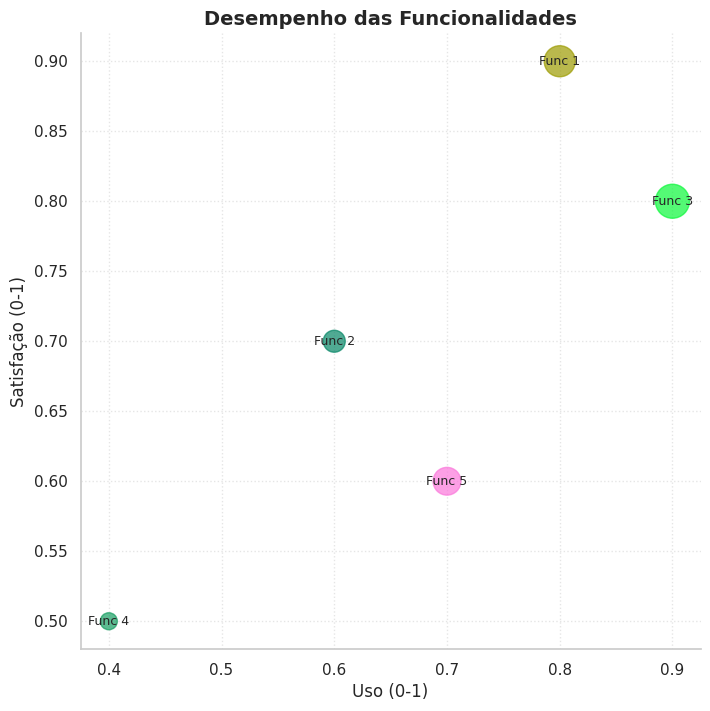

In [ ]:
# Dados para o Desafio 2.5
dados_funcionalidades = {
    'Funcionalidade': [f'Func {i}' for i in range(1, 6)],
    'Uso': [0.8, 0.6, 0.9, 0.4, 0.7],
    'Satisfacao': [0.9, 0.7, 0.8, 0.5, 0.6],
    'Impacto': [100, 50, 120, 30, 80]
}
df_funcionalidades = pd.DataFrame(dados_funcionalidades)

plt.figure(figsize=(8, 8))
plt.scatter(x=df_funcionalidades['Uso'], y=df_funcionalidades['Satisfacao'],
            s=df_funcionalidades['Impacto']*5, # Multiplicar para bolhas maiores
            alpha=0.7,
            c=np.random.rand(len(df_funcionalidades), 3)) # Cores aleatórias

for i, row in df_funcionalidades.iterrows():
    plt.text(row['Uso'], row['Satisfacao'], row['Funcionalidade'], fontsize=9, ha='center', va='center')

plt.title('Desempenho das Funcionalidades', fontsize=14, fontweight='bold')
plt.xlabel('Uso (0-1)', fontsize=12)
plt.ylabel('Satisfação (0-1)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

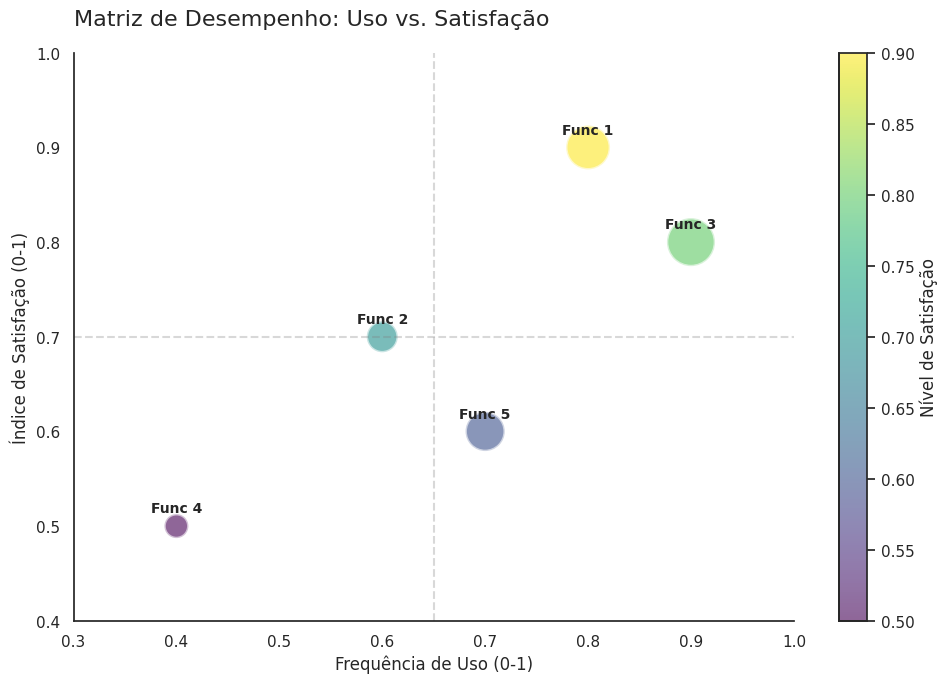

In [21]:
# 1. Problemas identificados:
#a)Codificação Ineficiente (Cleveland-McGill): O uso de cores aleatórias não comunica dado nenhum. A cor deveria ser usada para reforçar uma métrica ou categorizar os grupos, não apenas como decoração.
#b)Dificuldade de Comparação (Tufte): Sem uma legenda de escala para o tamanho das bolhas, o "Impacto" torna-se subjetivo. É difícil para o gerente saber se a Func 3 é exatamente o dobro ou apenas um pouco maior que a Func 5.
#c)Falta de Contexto (Gestalt): As bolhas estão "soltas" no espaço. Sem linhas de referência (como médias ou quadrantes), fica difícil identificar rapidamente quais funcionalidades são prioridades (ex: alto uso, mas baixa satisfação).

# 2. Seu código Python refatorado:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dados
dados_funcionalidades = {
    'Funcionalidade': [f'Func {i}' for i in range(1, 6)],
    'Uso': [0.8, 0.6, 0.9, 0.4, 0.7],
    'Satisfacao': [0.9, 0.7, 0.8, 0.5, 0.6],
    'Impacto': [100, 50, 120, 30, 80]
}
df = pd.DataFrame(dados_funcionalidades)

plt.figure(figsize=(10, 7))
sns.set_style("white")


#Tamanho das bolhas com escala consistente
scatter = plt.scatter(x=df['Uso'], y=df['Satisfacao'],
                      s=df['Impacto']*10,
                      c=df['Satisfacao'], cmap='viridis',
                      alpha=0.6, edgecolors='w', linewidth=2)

# Adicionando barra de cores para dar significado ao tom
cbar = plt.colorbar(scatter)
cbar.set_label('Nível de Satisfação')

# Quadrantes de Análise (Contexto de Negócio)
plt.axhline(0.7, color='grey', linestyle='--', alpha=0.3)
plt.axvline(0.65, color='grey', linestyle='--', alpha=0.3)

# Rótulos ajustados (Gestalt: Proximidade sem sobreposição direta)
for i, row in df.iterrows():
    plt.annotate(row['Funcionalidade'],
                 (row['Uso'], row['Satisfacao']),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center', fontsize=10, fontweight='bold')

# Estética final
sns.despine()
plt.title('Matriz de Desempenho: Uso vs. Satisfação', fontsize=16, loc='left', pad=20)
plt.xlabel('Frequência de Uso (0-1)')
plt.ylabel('Índice de Satisfação (0-1)')
plt.xlim(0.3, 1.0)
plt.ylim(0.4, 1.0)

plt.tight_layout()
plt.show()